## 1 Define ML application

- The goal of this ML application is to predict the **LogP (partition coefficient)** of molecules based on their chemical descriptors. This prediction can aid in **drug discovery and compound optimization** by providing insights into a molecule's lipophilicity, a critical factor for absorption, distribution, metabolism, and excretion (ADME) properties.  


> X =   
> y =


Here, `X` represents the feature matrix (molecular descriptors) and `y` represents the target vector (LogP values) for the entire dataset, before splitting into training and testing sets.

## 2 Load data

In [32]:
import pandas as pd
# Raw URL for the parquet file on GitHub
dataset_url = "https://raw.githubusercontent.com/DrCOAST/coast-python/main/data/logP.parquet"
# Load the parquet file into a pandas DataFrame
df = pd.read_parquet(dataset_url)
# Display the DataFrame
df

,SMILES,pIC50,logP
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,4.15910
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,3.67430
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,1.53610
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,0.95100
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,3.21300
...,...,...,...
16082,S=C(NN=C(c1ccccn1)c1ccccn1)Nc1ccccc1,0.00,3.21560
16083,S=C=NCCCCCCCCCCc1ccccc1,0.00,5.45270
16084,S=C=NCCCCCCCCc1ccccc1,0.00,4.67250
16085,S=c1[nH]nc(Cn2ccc3ccccc32)n1-c1ccccc1,0.00,3.93289


**pIC50**:   
This is a measure of the potency of a substance in inhibiting a specific biological function or process. It's the negative logarithm of the IC50 (half maximal inhibitory concentration). A higher pIC50 value indicates a more potent inhibitor.

**logP**:  
This represents the logarithm of the partition coefficient (P) of a compound between two immiscible phases, typically octanol and water. It's a measure of a molecule's lipophilicity (fat-loving) or hydrophilicity (water-loving). A higher logP indicates greater lipophilicity, while a lower or negative logP indicates greater hydrophilicity.  
> data from https://www.kaggle.com/datasets/yanmaksi/big-molecules-smiles-dataset


---
SOLUTION
---

## 3 Explore, standardize and clean

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16087 entries, 0 to 16086
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  16087 non-null  object 
 1   pIC50   15037 non-null  float64
 2   logP    16087 non-null  float64
dtypes: float64(2), object(1)
memory usage: 377.2+ KB


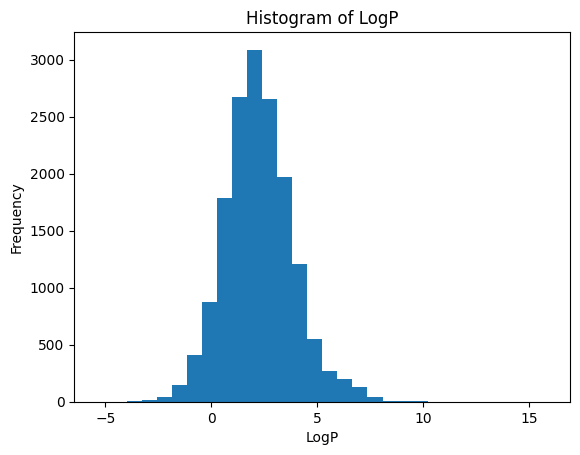

In [34]:
# plot histogram logP
import matplotlib.pyplot as plt
plt.hist(df['logP'], bins=30)
plt.xlabel('LogP')
plt.ylabel('Frequency')
plt.title('Histogram of LogP')
plt.show()

In [ ]:
# add mol objects

In [35]:
! pip install rdkit

In [36]:
# add mol objects to df
from rdkit import Chem
df['mol'] = df['SMILES'].apply(Chem.MolFromSmiles)
len(df)

16087

In [37]:
# remove invalid smiles
df = df[df['mol'].notna()]
len(df)

16087

In [38]:
# Canonicolize smiles
df['canonical_smiles'] = df['mol'].apply(Chem.MolToSmiles)
df

,SMILES,pIC50,logP,mol,canonical_smiles
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,4.15910,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a19930>,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,3.67430,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1b680>,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,1.53610,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1ac70>,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,0.95100,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1b610>,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,3.21300,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1ac00>,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1
...,...,...,...,...,...
16082,S=C(NN=C(c1ccccn1)c1ccccn1)Nc1ccccc1,0.00,3.21560,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb090e0>,S=C(NN=C(c1ccccn1)c1ccccn1)Nc1ccccc1
16083,S=C=NCCCCCCCCCCc1ccccc1,0.00,5.45270,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb09150>,S=C=NCCCCCCCCCCc1ccccc1
16084,S=C=NCCCCCCCCc1ccccc1,0.00,4.67250,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb091c0>,S=C=NCCCCCCCCc1ccccc1
16085,S=c1[nH]nc(Cn2ccc3ccccc32)n1-c1ccccc1,0.00,3.93289,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb09230>,S=c1[nH]nc(Cn2ccc3ccccc32)n1-c1ccccc1


In [39]:
# remove duplicates canonical smiles
df = df.drop_duplicates(subset=['canonical_smiles']).copy()
len(df)

15872

## 4 Featurization

In [40]:
# add (meaningfull) descriptors
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

df['MW'] = df['mol'].apply(Descriptors.MolWt)
# df['MolLogP_Descriptor'] = df['mol'].apply(Descriptors.MolLogP) # Renamed to avoid overwriting target logP
df['TPSA'] = df['mol'].apply(Descriptors.TPSA)
df['NumHDonors'] = df['mol'].apply(Descriptors.NumHDonors)
df['NumHAcceptors'] = df['mol'].apply(Descriptors.NumHAcceptors)
df['NumRotatableBonds'] = df['mol'].apply(Descriptors.NumRotatableBonds)

df

,SMILES,pIC50,logP,mol,canonical_smiles,MW,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,4.15910,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a19930>,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,367.455,71.95,1,5,4
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,3.67430,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1b680>,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,506.434,149.78,4,5,7
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,1.53610,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1ac70>,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,317.389,101.37,3,4,5
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,0.95100,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1b610>,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,301.394,98.96,3,4,5
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,3.21300,<rdkit.Chem.rdchem.Mol object at 0x7b6cb5a1ac00>,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,294.383,49.84,2,3,2
...,...,...,...,...,...,...,...,...,...,...
16082,S=C(NN=C(c1ccccn1)c1ccccn1)Nc1ccccc1,0.00,3.21560,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb090e0>,S=C(NN=C(c1ccccn1)c1ccccn1)Nc1ccccc1,333.420,62.20,2,4,4
16083,S=C=NCCCCCCCCCCc1ccccc1,0.00,5.45270,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb09150>,S=C=NCCCCCCCCCCc1ccccc1,275.461,12.36,0,2,11
16084,S=C=NCCCCCCCCc1ccccc1,0.00,4.67250,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb091c0>,S=C=NCCCCCCCCc1ccccc1,247.407,12.36,0,2,9
16085,S=c1[nH]nc(Cn2ccc3ccccc32)n1-c1ccccc1,0.00,3.93289,<rdkit.Chem.rdchem.Mol object at 0x7b6caeb09230>,S=c1[nH]nc(Cn2ccc3ccccc32)n1-c1ccccc1,306.394,38.54,1,2,3


In [42]:
descriptor_columns = ['MW', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds']
X = df[descriptor_columns]
y = df['logP']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (15872, 5)
Shape of y: (15872,)


## 5 Split data

In [44]:
#split dataset
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [45]:
descriptor_columns = ['MW', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds']
X_train = train_df[descriptor_columns]
y_train = train_df['logP']
X_test = test_df[descriptor_columns]
y_test = test_df['logP']
len(X_train), len(y_train), len(X_test), len(y_test)

(12697, 12697, 3175, 3175)

## 6  Choose and built model

- Linear Regression: A simple, interpretable model that assumes a linear relationship between features and the target variable.
- Random Forest Regressor: An ensemble learning method that builds multiple decision trees and merges their predictions to improve accuracy and control overfitting. (Already demonstrated)
- Gradient Boosting Regressor (e.g., XGBoost, LightGBM): Another powerful ensemble method that builds trees sequentially, with each new tree correcting errors made by previous ones.
- Support Vector Regressor (SVR): A robust model that finds a hyperplane to best fit the data, often effective in high-dimensional spaces.
- Neural Networks (e.g., Multi-layer Perceptron): Can capture complex non-linear relationships in the data, though they often require more data and tuning.
- K-Nearest Neighbors Regressor (KNN): A non-parametric method that predicts based on the average of the 'k' nearest data points in the feature space.

In [46]:
# Model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

## 7 Train model

In [47]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## 8 Evaluate model

In [48]:
# Evaluate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 0.507206867942895
Root Mean Squared Error (RMSE): 0.7121845743505647
Mean Absolute Error (MAE): 0.45262412404880786
R-squared (R2): 0.8053485120698132


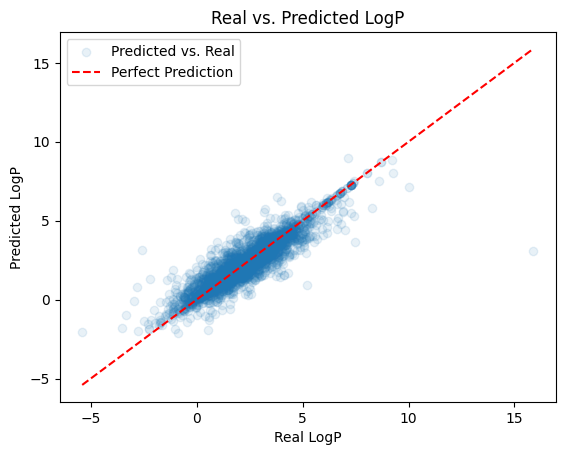

In [49]:
# plot predicted versus real
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, label='Predicted vs. Real', alpha=0.1)
plt.xlabel("Real LogP")
plt.ylabel("Predicted LogP")
plt.title("Real vs. Predicted LogP")

# Add line for perfect prediction
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.legend()
plt.show()

Extra: make plot interactive !!

In [50]:
pip install plotly

In [51]:
import plotly.graph_objects as go

# Create scatter plot for predicted vs real
scatter_trace = go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    name='Predicted vs. Real',
    marker=dict(opacity=0.3)
)

# Add line for perfect prediction
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
line_trace = go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red', dash='dash')
)

# Create layout
layout = go.Layout(
    title='Interactive: Real vs. Predicted LogP',
    xaxis=dict(title='Real LogP'),
    yaxis=dict(title='Predicted LogP'),
    hovermode='closest'
)

# Create figure and add traces
fig = go.Figure(data=[scatter_trace, line_trace], layout=layout)

# Display the interactive plot
fig.show()

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get the descriptor names
descriptor_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': descriptor_names, 'Importance': feature_importances})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

Feature Importances:
             Feature  Importance
1               TPSA    0.441141
0                 MW    0.429187
4  NumRotatableBonds    0.049407
2         NumHDonors    0.045862
3      NumHAcceptors    0.034403


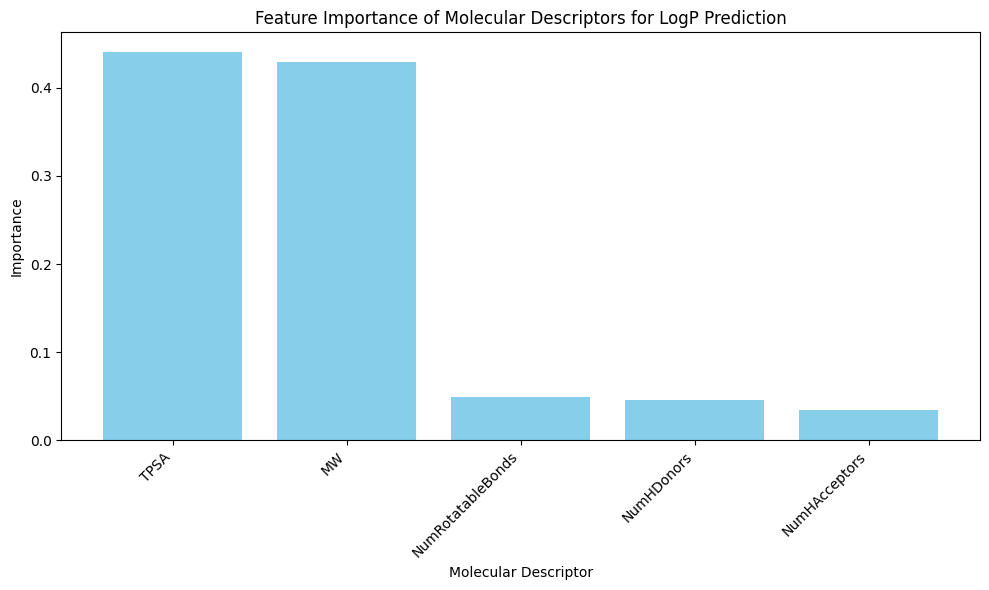

In [60]:
fig = plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Molecular Descriptor')
plt.ylabel('Importance')
plt.title('Feature Importance of Molecular Descriptors for LogP Prediction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The bar chart above shows the relative importance of each molecular descriptor in predicting LogP values using the Random Forest model. A higher bar indicates a greater contribution of that descriptor to the model's predictive power.

From the plot, we can observe which descriptors the model found most influential. Typically:
- **MW (Molecular Weight)**: Often a significant factor as larger molecules tend to have different LogP characteristics.
- **TPSA (Topological Polar Surface Area)**: Reflects the polarity of a molecule, which is directly related to its hydrophilicity/lipophilicity.
- **NumHDonors (Number of Hydrogen Bond Donors)** and **NumHAcceptors (Number of Hydrogen Bond Acceptors)**: These indicate a molecule's ability to form hydrogen bonds, influencing its solubility and partitioning behavior.
- **NumRotatableBonds (Number of Rotatable Bonds)**: Can affect a molecule's flexibility and conformational space, indirectly impacting its interactions and partitioning.

The specific order and magnitude of these importances highlight which chemical properties are most crucial for accurate LogP prediction by this particular model.

## 9 Improve model

## Save, Load  and Use model

In [52]:
# save model
import pickle
with open('/content/drive/MyDrive/COAST COURSE/FINAL/model_logP.pkl', 'wb') as f:
    pickle.dump(model, f)



In [53]:
# load model
import pickle
with open('/content/drive/MyDrive/COAST COURSE/FINAL/model_logP.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
# use model


### Predict `logP` for a New Molecule

To predict the `logP` of a new molecule, we need to follow these steps:
1.  Define the SMILES string for the new molecule.
2.  Calculate the same molecular descriptors (`MW`, `TPSA`, `NumHDonors`, `NumHAcceptors`, `NumRotatableBonds`) that were used to train the model.
3.  Use the `loaded_model` to make a prediction based on these descriptors.

In [54]:
# 1. Define a new SMILES string for a molecule you want to predict
new_smiles = "CC(=O)Oc1ccccc1C(=O)O" # Aspirin
print(f"New molecule SMILES: {new_smiles}")

New molecule SMILES: CC(=O)Oc1ccccc1C(=O)O


In [55]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

# 2. Convert SMILES to RDKit Mol object and calculate descriptors
new_mol = Chem.MolFromSmiles(new_smiles)

# Calculate each descriptor
new_mw = Descriptors.MolWt(new_mol)
new_tpsa = Descriptors.TPSA(new_mol)
new_numhdonors = Descriptors.NumHDonors(new_mol)
new_numhacceptors = Descriptors.NumHAcceptors(new_mol)
new_numrotatablebonds = Descriptors.NumRotatableBonds(new_mol)

# Create a DataFrame for the new molecule's features
# Ensure the column names match those used during training
new_molecule_features = pd.DataFrame([[new_mw, new_tpsa, new_numhdonors, new_numhacceptors, new_numrotatablebonds]],
                                      columns=['MW', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds'])

print("Calculated features for the new molecule:")
print(new_molecule_features)

Calculated features for the new molecule:
        MW  TPSA  NumHDonors  NumHAcceptors  NumRotatableBonds
0  180.159  63.6           1              3                  2


In [56]:
# 3. Use the loaded model to predict the logP
predicted_logP = loaded_model.predict(new_molecule_features)

# Display the predicted logP
print(f"The predicted LogP for the new molecule ({new_smiles}) is: {predicted_logP[0]:.4f}")

The predicted LogP for the new molecule (CC(=O)Oc1ccccc1C(=O)O) is: 1.2473


Experimental logP of aspirin 1.2 - 1.3  